In [5]:
from pathlib import Path
from cds_synthetic_cdo import CDSPanel, ProjectPaths

paths = ProjectPaths(Path("/Users/ktmac/Documents/quant"))
panel = CDSPanel.load("cds.csv")
df = panel.frame
df_cds = df  # alias cho mục EDA / CDO


In [6]:
# Cột Date đã được chuẩn hóa trong CDSPanel.load


In [7]:
df.columns

Index(['Date', 'Ticker', 'Company', 'PX1', 'PX2', 'PX3', 'PX4', 'PX5', 'PX6',
       'PX7', 'PX8', 'PX9', 'PX10'],
      dtype='object')

In [8]:
from pathlib import Path
from cds_synthetic_cdo import CDSPanel, ProjectPaths

paths = ProjectPaths(Path("/Users/ktmac/Documents/quant"))
if "panel" not in dir():
    panel = CDSPanel.load(paths.cds_csv)
    df = panel.frame
wide = {k: panel.wide_tenor(k) for k in range(1, 11)}
df1, df2, df3, df4, df5, df6, df7, df8, df9, df10 = [wide[k] for k in range(1, 11)]


In [9]:
df1

Ticker,A,AALLN,AAPL,ABBNVX,ABBV,ABC,ABESM,ABIBB,ABT,ABXCN,...,WMB,WMT,WOORIB,WPLAU,WSTP,WU,WY,XL,XOM,ZIGGO
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,14.8500,32.8350,8.3000,5.8200,NaN,7.3550,26.2750,14.5200,4.9400,25.2600,...,42.4400,4.5000,14.0200,32.2300,7.4000,15.3600,7.6800,9.5050,16.1000,NaN
2015-01-02,14.8550,32.7000,8.3000,5.8000,NaN,7.3600,26.5750,13.8100,4.9400,25.9700,...,43.6800,4.4650,14.0700,31.2400,7.6850,15.5600,7.2850,4.4650,16.1050,NaN
2015-01-05,13.4550,34.2350,9.5350,5.8550,NaN,7.3550,26.0750,14.0700,4.9400,25.9550,...,43.6750,4.4250,14.3200,32.5600,7.7450,19.6200,7.6300,4.9250,15.8150,NaN
2015-01-06,15.5350,37.9000,7.8200,6.0950,NaN,7.5100,27.1550,14.2100,5.1250,25.5550,...,44.3200,4.3650,14.9700,34.6100,8.2700,14.8950,6.8750,4.8650,16.0850,NaN
2015-01-07,15.2150,33.5200,7.8350,6.0950,NaN,7.3350,27.0250,14.7650,4.9300,26.7050,...,44.1850,4.3700,15.3000,33.1000,8.2150,15.7300,6.8800,4.9550,20.8200,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-06,23.3313,21.5761,8.9743,13.5824,35.1256,14.9503,18.7102,24.7570,9.2299,9.7966,...,17.2233,6.3988,4.7145,15.5279,7.0315,21.6400,8.7080,4.9906,6.9708,43.1264
2021-09-07,23.4577,21.6490,9.0938,13.7947,37.0837,14.8010,18.6308,25.0653,9.2624,9.5502,...,18.6012,6.7951,4.7619,15.1021,6.9673,21.6248,8.3925,4.5653,6.9284,43.1224
2021-09-08,25.5318,21.6751,9.0012,13.7662,34.9703,15.0629,18.8526,25.2241,9.3093,9.6930,...,18.8461,6.8017,4.7012,15.4879,6.8653,21.9579,8.4952,4.5323,7.0292,42.3178


<Axes: xlabel='Date'>

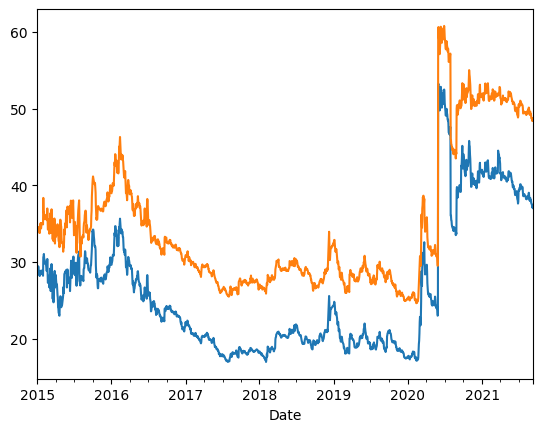

In [10]:
df5["ABBNVX"].plot()
df10["ABBNVX"].plot()

<Axes: xlabel='Date'>

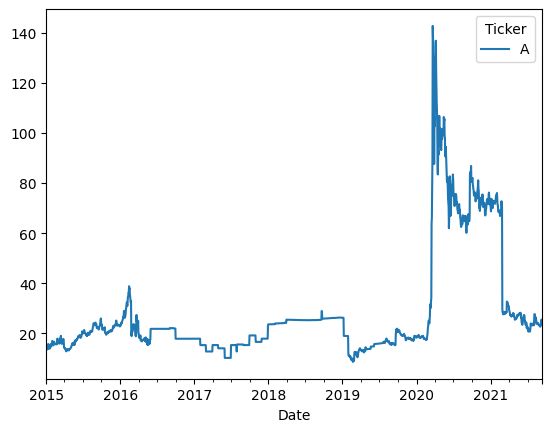

In [11]:
df1[["A"]].plot()

# Synthetic CDO từ dữ liệu CDS — Notebook có cấu trúc

**Dữ liệu:** `cds.csv` — spread theo kỳ **PX1…PX10** (≈ 1Y…10Y, **bp**), theo `Date` × `Ticker`.

### Mục lục

1. **Dữ liệu & EDA** — phạm vi thời gian, thiếu dữ liệu, phân phối spread (PX1/5/10), trung bình ngang theo ngày.
2. **Phụ thuộc (dependence)** — ma trận tương quan **ΔPX5**, rolling **mean |ρ|**, scatter cặp ticker, **copula Gauss 2D**; **PCA (PC1)** trên biến động spread như yếu tố chung.
3. **Định giá Synthetic CDO** — spread → PD, copula một nhân, Monte Carlo, tranche; **§3.2b** (Mounfield): compound/base correlation, LHP, EL tranche bằng tích phân, đường $\rho_{\mathrm{base}}(K)$.

**Code:** logic tập trung trong `cds_synthetic_cdo.py` (`ProjectPaths`, `CDSPanel`, `SyntheticCDOParams`, `SyntheticCDOEngine`, v.v.).

**Giả định chung:** recovery $R=40\%$ khi chuyển spread → hazard (minh họa); có thể chỉnh `VAL_DATE`, `pool_size`, `rho`, `tranches` trong `SyntheticCDOParams` (ô 3.1).

## 1. Dữ liệu CDS & EDA

Ta phân tích cấu trúc file, phạm vi ngày, số ticker, tỷ lệ thiếu, phân phối spread (ví dụ **PX5**), và một số thống kê theo thời gian (trung bình ngang mặt cắt).

*Chạy ô dưới (có thể độc lập phần đầu notebook nếu đã `import pandas`).*

=== Cấu trúc ===
(1061167, 13)
Date       datetime64[ns]
Ticker             object
Company            object
PX1               float64
PX2               float64
PX3               float64
PX4               float64
PX5               float64
PX6               float64
PX7               float64
PX8               float64
PX9               float64
PX10              float64
dtype: object

=== Phạm vi ngày ===
2015-01-01 00:00:00 → 2021-09-10 00:00:00
Số ticker khác nhau: 661
Số quan sát / ngày (median): 609.0

=== Tỷ lệ thiếu theo cột PX (top) ===
PX1    0.0
PX2    0.0
PX3    0.0
PX4    0.0
PX5    0.0
PX6    0.0


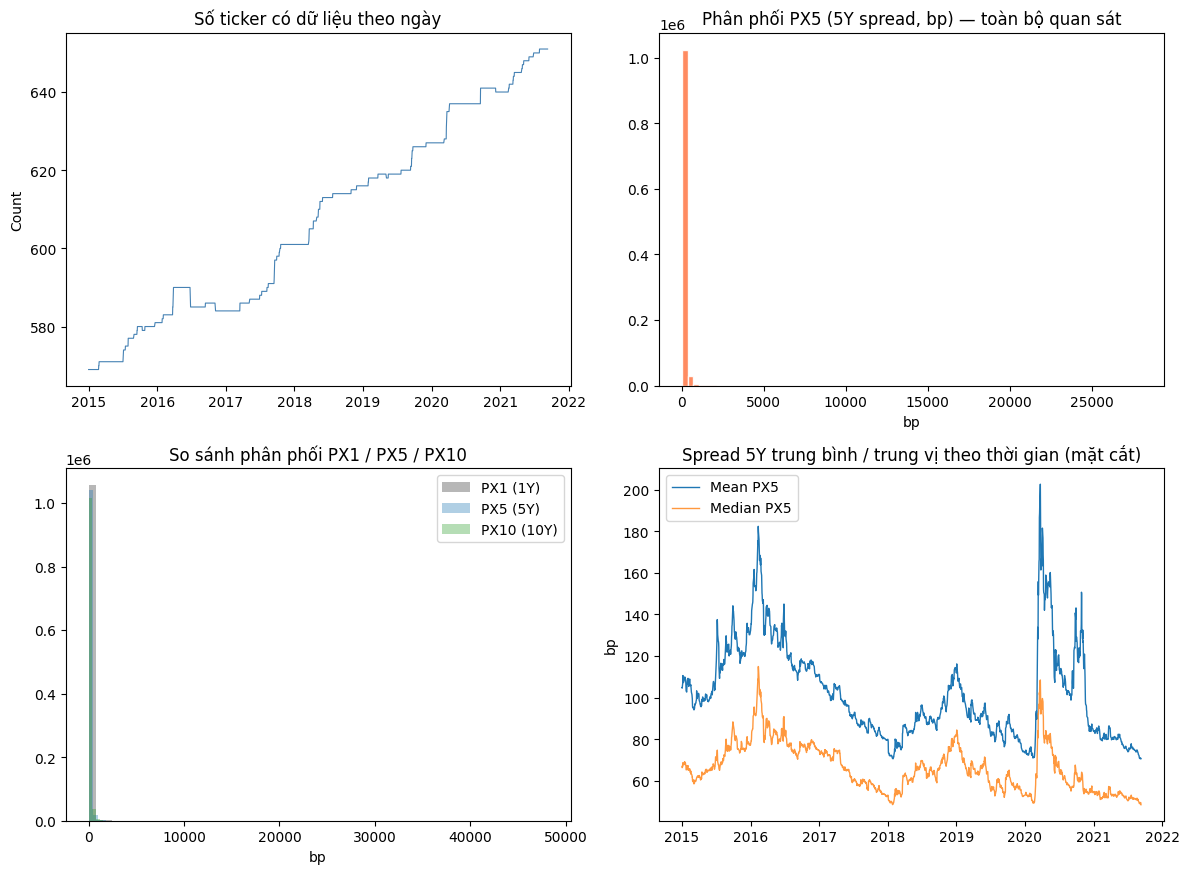

,count,mean,std,min,5%,50%,95%,max
PX1,1061167.0,41.20,249.33,1.15,5.26,14.87,116.76,48115.24
PX2,1061167.0,53.68,202.32,2.07,8.14,24.68,160.56,34522.49
PX3,1061167.0,68.91,187.77,3.35,12.22,36.75,206.58,32246.85
PX4,1061167.0,85.41,177.12,4.80,17.60,50.92,249.04,30048.36
PX5,1061167.0,101.52,171.83,5.80,23.32,64.99,292.68,28017.64
PX6,1061167.0,114.92,167.03,9.48,29.90,77.76,320.71,26671.76
PX7,1061167.0,124.58,164.14,10.95,34.49,86.88,341.55,25561.03
PX8,1061167.0,131.12,161.51,12.68,38.48,93.50,353.27,24590.86
PX9,1061167.0,136.22,159.47,14.26,41.66,98.70,357.87,23763.96
PX10,1061167.0,140.27,157.83,14.91,44.15,102.89,364.73,23052.64


In [12]:
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

from cds_synthetic_cdo import print_eda_text_summary

if "panel" not in dir():
    from pathlib import Path
    from cds_synthetic_cdo import CDSPanel, ProjectPaths

    paths = ProjectPaths(Path("/Users/ktmac/Documents/quant"))
    panel = CDSPanel.load(paths.cds_csv)
    df_cds = panel.frame
else:
    df_cds = panel.frame

print_eda_text_summary(panel)
fig = panel.plot_eda_summary()
plt.show()
display(panel.describe_px())


## 2. Phụ thuộc (dependence) giữa các CDS

**Ý tưởng:** spread các tên cùng thị trường thường **đồng biến** (sợ rủi ro hệ thống). Ta xem:

- **Ma trận tương quan Pearson** của *thay đổi* spread (hoặc log-return) trên một tập ticker có đủ dữ liệu.
- **Tương quan trung bình theo thời gian** (rolling window): mức độ “dính nhau” của thị trường CDS tăng/giảm trong khủng hoảng.
- **Scatter** cặp tên (ví dụ hai ticker có nhiều điểm chung).
- **Copula Gauss** (minh họa): nếu biên là chuẩn, cặp $(Z_1,Z_2)$ với cùng factor $Y$ có tương quan $\rho$; đây là **cùng họ** với mô hình một nhân dùng trong CDO (mở rộng lên $n$ tên).

*Lưu ý:* tương quan **thống kê** (ước từ dữ liệu) ≠ **tham số ρ** (asset correlation) trong mô hình cấu trúc — nhưng cùng định hướng: khi ρ cao, default **đồng thời** nhìn chung dễ xảy ra hơn.

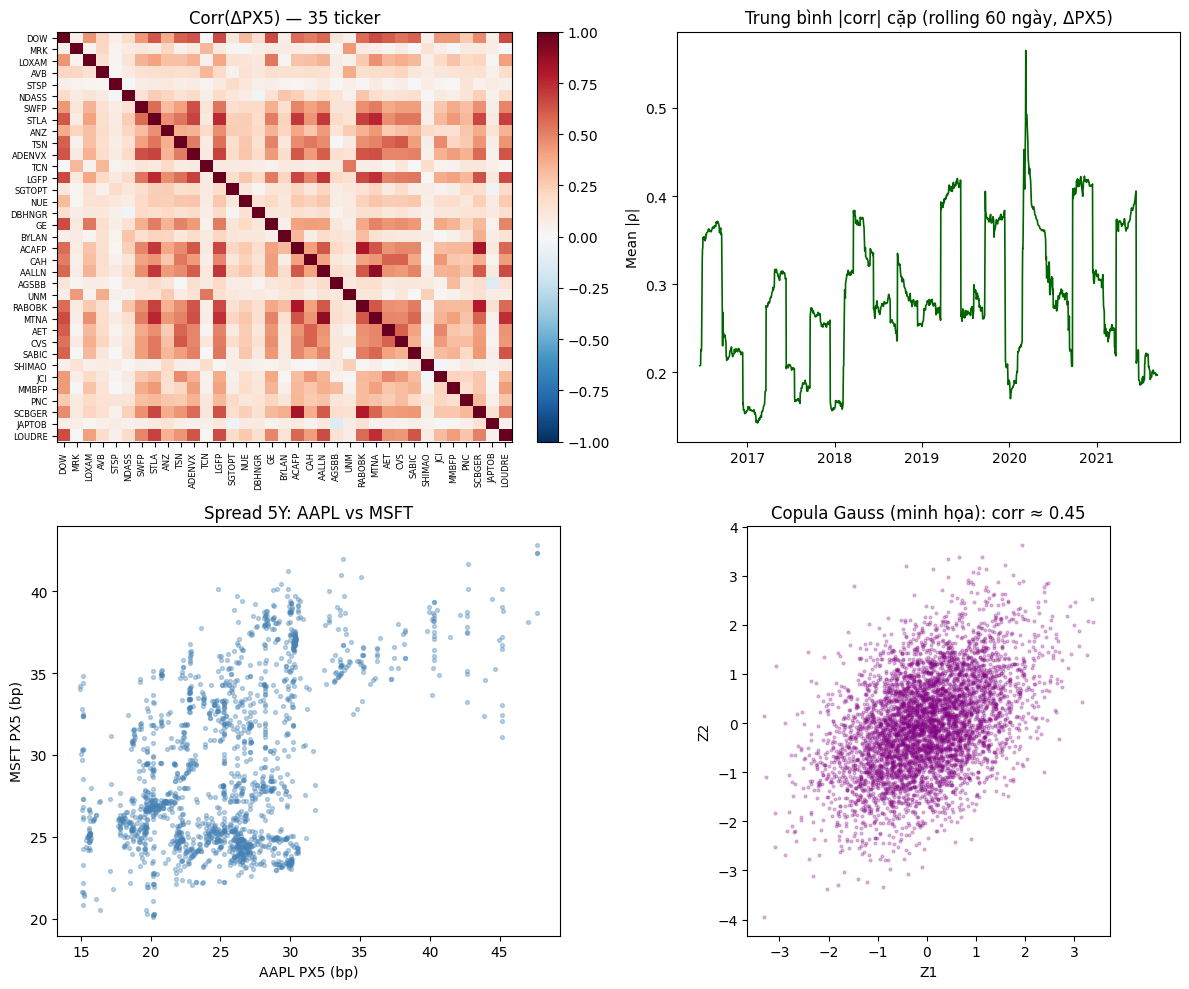

Corr mức spread AAPL vs MSFT (PX5): 0.50
Corr mức thay đổi ΔPX5: 0.24


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path
from cds_synthetic_cdo import CDSPanel, DependencePlotParams, ProjectPaths

if "panel" not in dir():
    panel = CDSPanel.load(ProjectPaths(Path("/Users/ktmac/Documents/quant")).cds_csv)

# Đổi tham số tại đây, hoặc sau ô 3.1: cfg = params.dependence_plot
cfg = DependencePlotParams()
fig = panel.plot_dependence_quadrant(cfg)
plt.show()
panel.dependence_summary(cfg)


### 2.1 Yếu tố chung (PCA) trên biến động spread

**Ý tưởng:** nếu nhiều CDS **cùng nhạy** với một nhịp rủi ro hệ thống, thành phần chính đầu tiên (PC1) của ma trận hiệp phương sai của **ΔPX5** giải thích một phần lớn phương sai — tương tự “factor” trong copula một nhân (không đồng nhất nhưng cùng hướng).

Số ticker dùng PCA: 581 | số ngày: 1426


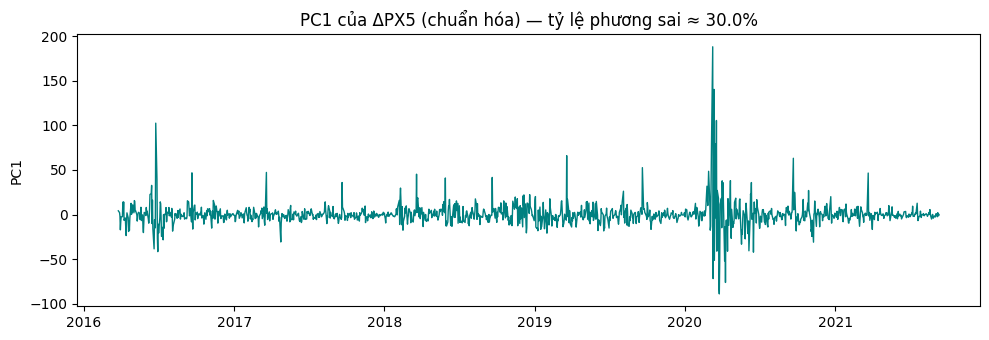

In [14]:
import matplotlib.pyplot as plt

if "panel" not in dir():
    raise RuntimeError("Chạy ô load CDS / EDA trước để có `panel`.")

fig = panel.plot_pca_pc1()
if fig is not None:
    plt.show()


## 3. Định giá Synthetic CDO

**Luồng:** từ đường cong spread (PX1…PX10) → **PD(0,T)** (hazard đoạn) → **Gaussian copula một nhân** với tham số **ρ** (do người dùng chọn; khác với ρ thống kê ở mục 2) → Monte Carlo **tổn thất danh mục** → **tranche** [A,D] và spread gần đúng.

Các ô dưới: (3.1) tham số & pool, (3.2) hàm + kết quả tranche, **(3.2b)** ý tưởng từ Mounfield (2008): LHP, compound/base correlation, (3.3) hình vẽ.

### 3.1 Tham số & chọn pool định giá

Điều chỉnh `SyntheticCDOParams`: `val_date`, `pool_size`, `rho`, `tranches`, và các khối con `dependence_plot`, `dashboard_plot`, `mounfield_plot` (xem class trong `cds_synthetic_cdo.py`).

In [15]:
quay

NameError: name 'quay' is not defined

### 3.2 Hazard, copula một nhân, Monte Carlo & bảng tranche

In [ ]:
engine.run_monte_carlo()
res_df = engine.tranche_table()

el_portfolio = engine.loss_paths.mean()
print(f"Expected portfolio loss fraction (5Y, ρ={params.rho}): {el_portfolio:.4%}")
res_df


Expected portfolio loss fraction (5Y, ρ=0.22): 2.7355%


,tranche,attach,detach,EL,spread_approx_bp
0,Equity,0.00,0.03,0.576113,38407.500000
1,Mezz,0.03,0.07,0.179075,8953.750000
2,Senior,0.07,0.10,0.057181,3812.083333


### 3.2b Kỹ thuật từ Mounfield (2008) — *Synthetic CDOs: Modelling, Valuation and Risk Management*

*Chạy ô **3.1**, **3.2** (`engine.run_monte_carlo()`) trước — cần `engine` với `p_vec` đã tính.*

Tham khảo **C. C. Mounfield**, Cambridge University Press (2008). Các ý chính thường dùng trong thực hành (trước/khủng hoảng 2008):

| Khái niệm | Ý nghĩa ngắn |
|-----------|----------------|
| **Gaussian copula một nhân** | Factor chung \(Y\): điều kiện trên \(Y\), xác suất vỡ nợ \(p(Y)=\Phi\big(\frac{\Phi^{-1}(PD)-\sqrt{\rho}\,Y}{\sqrt{1-\rho}}\big)\). |
| **Compound correlation** | Một \(\rho\) **riêng cho từng tranche** để khớp giá thị trường (mỗi tranche một \(\rho\) khác nhau). |
| **Base correlation** | Với mỗi **detachment** \(K\), tìm \(\rho_{\mathrm{base}}(K)\) sao cho tranche **first-loss** \([0,K]\) (định nghĩa theo notional danh mục) khớp quote — tạo **đường cong** \(\rho_{\mathrm{base}}(K)\). Thị trường thường **không phẳng** (một \(\rho\) duy nhất không fit mọi tranche). |
| **LHP / Vasicek** | Pool **đồng nhất**, \(n\) lớn: tổn thất điều kiện trên \(Y\) gần **xác định** \(L\mid Y \approx (1-R)\,p(Y)\). |

**Điểm quan trọng:** Với pool **đồng nhất** (cùng \(PD\)), **expected loss toàn danh mục** \(E[L]=(1-R)\cdot PD\) **không đổi** theo \(\rho\); \(\rho\) chỉ đổi **phân phối** và giá **tranche** (đặc biệt equity/mezz). Ô code dưới: tính **EL tranche equity** \([0,d]\) bằng **tích phân** (điều kiện Binomial — ổn định hơn MC khi cần root-finding), so sánh **LHP**, và vẽ **đường base correlation** khi “khớp ngược” từ cùng một mục tiêu (kiểm tra mã khôi phục \(\rho\) gần đúng).

**Rủi ro (sách còn nhắc):** độ nhạy \(\rho\) (correlation delta), spread / CS01 — khi quote tranche thay đổi, \(\rho_{\mathrm{base}}(K)\) thay đổi theo (định tính).

*Nguồn PDF không có trong workspace — nội dung tóm tắt theo cách trình bày chuẩn của sách; đọc các chương về copula, implied/base correlation và risk trong bản in để khớp định nghĩa thị trường.*

--- Pool đồng nhất (median PD) ---
PD (median) = 0.0304
E[L] toàn danh mục (lý thuyết) = (1-R)*PD = 1.8249%

Tranche equity [0, 3%]: EL/d — finite n=80: 0.3841 | LHP: 0.4071
Khôi phục ρ từ target EL: 0.2800 (mục tiêu ρ = 0.28)


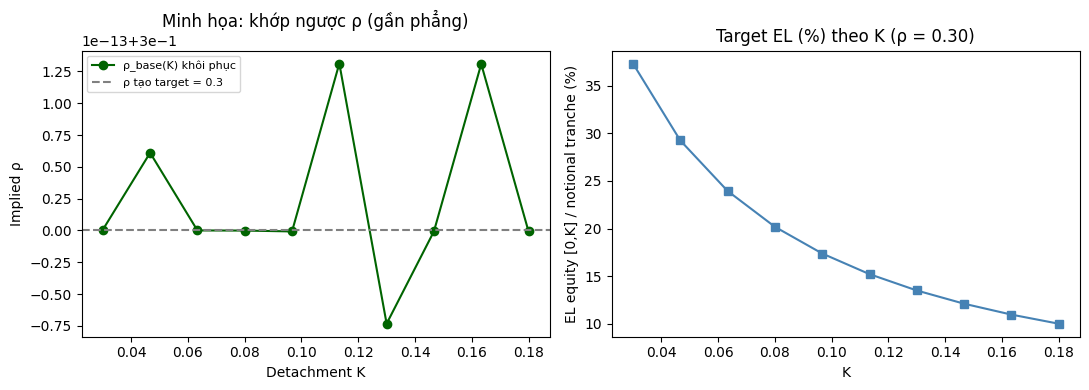

In [ ]:
import matplotlib.pyplot as plt

fig_m = engine.mounfield_figures()
plt.show()


### 3.3 Hình minh họa (phân phối tổn thất, nhạy ρ, spread pool)

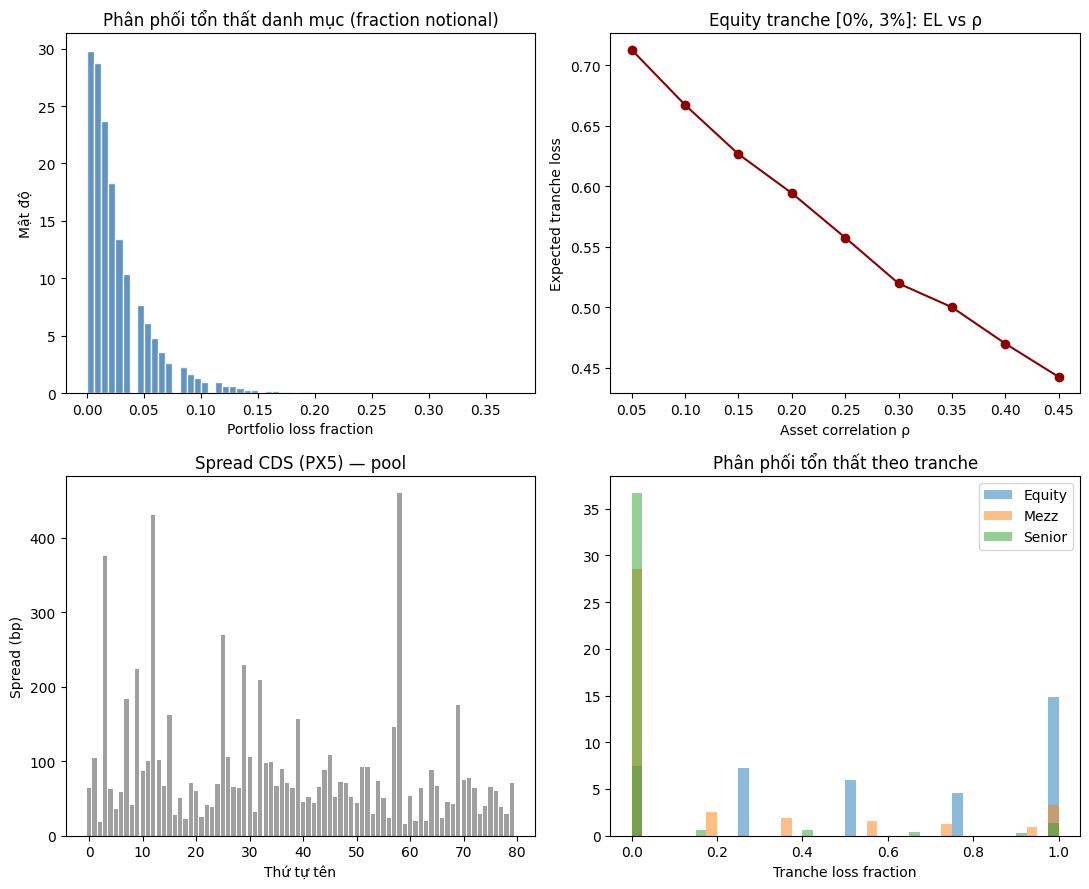

,piecewise_curve,px5_only_flat
count,80.000000,80.000000
mean,0.045681,0.068913
std,0.049431,0.059267
min,0.007110,0.012969
25%,0.020731,0.035190
50%,0.030415,0.052998
75%,0.046555,0.075367
max,0.310035,0.318295


In [ ]:
import matplotlib.pyplot as plt

fig, cmp_stats = engine.plot_cdo_dashboard()
plt.show()
cmp_stats


In [ ]:
# Logic nằm trong cds_synthetic_cdo.py (CDSPanel, SyntheticCDOEngine, ...).
# Chỉnh SyntheticCDOParams ở ô 3.1.
